In [10]:
# -------------------------------------------------
# Extension: Speech-preserving adaptive noise cancellation
# -------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt



def past_vector(signal, n, L):
    """
    Returns [signal[n], signal[n-1], ..., signal[n-L+1]]
    with zero-padding for negative indices.
    """
    vec = np.zeros(L)
    for k in range(L):
        if n - k >= 0:
            vec[k] = signal[n - k]
    return vec


def moving_average(x, window):
    """
    Simple moving average for smoother plots.
    """
    window = min(window, len(x))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")

def normalize(x, eps=1e-12):
    """
    Normalize signal to unit RMS.
    """
    return x / (np.sqrt(np.mean(x**2)) + eps)


def fir_filter(x, h):
    """
    Causal FIR filtering using convolution.
    Output has same length as x.
    """
    return np.convolve(x, h, mode="full")[:len(x)]


def scale_noise_to_snr(clean, noise, snr_db, eps=1e-12):
    """
    Scale noise so that clean + noise has the desired input SNR.
    """
    clean_power = np.mean(clean**2)
    noise_power = np.mean(noise**2) + eps
    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)
    return scale * noise, scale


def snr_db(clean, test, eps=1e-12):
    """
    SNR between clean signal and processed signal.
    test = clean + residual_noise_or_distortion
    """
    error = test - clean
    return 10 * np.log10((np.sum(clean**2) + eps) / (np.sum(error**2) + eps))


def speech_distortion(clean, test, eps=1e-12):
    """
    Normalized distortion relative to the clean speech.
    Smaller is better.
    """
    return np.sum((clean - test) ** 2) / (np.sum(clean**2) + eps)


def make_synthetic_speech(fs, T, seed=10):
    """
    Creates a simple speech-like signal.

    This is not real speech, but it has:
    - voiced harmonic content,
    - changing pitch,
    - syllable-like amplitude envelope,
    - small unvoiced/noisy components.

    Later you can replace this with a real .wav file.
    """
    rng = np.random.default_rng(seed)

    N = int(fs * T)
    t = np.arange(N) / fs

    # Slowly varying pitch, roughly speech-like
    f0 = 110 + 30 * np.sin(2 * np.pi * 0.35 * t) + 10 * np.sin(2 * np.pi * 0.9 * t)
    phase = 2 * np.pi * np.cumsum(f0) / fs

    voiced = (
        1.00 * np.sin(phase)
        + 0.50 * np.sin(2 * phase + 0.3)
        + 0.25 * np.sin(3 * phase + 0.7)
        + 0.15 * np.sin(4 * phase + 1.1)
    )

    # Syllable-like envelope
    envelope = 0.25 + 0.75 * np.maximum(0, np.sin(2 * np.pi * 1.7 * t)) ** 1.5

    # Add some unvoiced/fricative-like random component
    unvoiced = fir_filter(rng.standard_normal(N), np.array([1, -0.8]))
    unvoiced = normalize(unvoiced)

    speech = envelope * voiced + 0.08 * envelope * unvoiced
    speech = normalize(speech)

    return speech


def make_engine_like_noise(fs, T, seed=20):
    """
    Creates a colored noise source with low-frequency tonal components.
    This mimics fan/engine-like noise.
    """
    rng = np.random.default_rng(seed)
    N = int(fs * T)
    t = np.arange(N) / fs

    white = rng.standard_normal(N)

    # Simple low-pass-ish FIR coloring
    h_col = np.array([0.05, 0.10, 0.16, 0.20, 0.16, 0.10, 0.05])
    colored = fir_filter(white, h_col)

    # Tonal components inside the speech band
    tonal = (
        1.0 * np.sin(2 * np.pi * 60 * t)
        + 0.5 * np.sin(2 * np.pi * 120 * t + 0.4)
        + 0.25 * np.sin(2 * np.pi * 180 * t + 1.2)
    )

    noise = colored + 0.8 * tonal
    noise = normalize(noise)

    return noise


# -------------------------------------------------
# LMS adaptive noise canceller
# -------------------------------------------------

def run_lms_speech_anc(speech, primary_noise, reference_noise, M, mu, normalized=True):
    """
    Adaptive noise cancellation using ordinary LMS/NLMS.

    primary input:
        d(n) = speech(n) + primary_noise(n)

    reference input:
        x(n) = correlated noise measurement

    adaptive output:
        y(n) = estimated noise

    cleaned output:
        z(n) = d(n) - y(n)

    The goal is z(n) ≈ speech(n).
    """
    N = len(speech)

    w = np.zeros(M)

    primary = speech + primary_noise
    y = np.zeros(N)
    z = np.zeros(N)
    w_hist = np.zeros((N, M))

    eps = 1e-8

    for n in range(N):
        x_vec = past_vector(reference_noise, n, M)

        # Estimated noise
        y[n] = np.dot(w, x_vec)

        # Cleaned output / error signal
        z[n] = primary[n] - y[n]

        if normalized:
            denom = eps + np.dot(x_vec, x_vec)
            w = w + mu * z[n] * x_vec / denom
        else:
            w = w + mu * z[n] * x_vec

        w_hist[n, :] = w

    return {
        "primary": primary,
        "y_noise_est": y,
        "z_cleaned": z,
        "w_hist": w_hist,
        "residual": z - speech,
    }


# -------------------------------------------------
# Offline Wiener / least-squares baseline
# -------------------------------------------------

def run_wiener_speech_anc(speech, primary_noise, reference_noise, M, reg=1e-6):
    """
    Offline Wiener/least-squares baseline.

    This solves:
        min_w || primary - Xw ||^2

    where X contains delayed reference-noise samples.

    Since speech is assumed uncorrelated with the reference noise,
    the Wiener solution should mainly estimate the noise component.
    """
    N = len(speech)
    primary = speech + primary_noise

    X = np.zeros((N, M))
    for n in range(N):
        X[n, :] = past_vector(reference_noise, n, M)

    R = X.T @ X + reg * np.eye(M)
    p = X.T @ primary

    w = np.linalg.solve(R, p)

    y = X @ w
    z = primary - y

    return {
        "primary": primary,
        "y_noise_est": y,
        "z_cleaned": z,
        "w": w,
        "residual": z - speech,
    }


# -------------------------------------------------
# Filtered-X LMS headphone-style ANC
# -------------------------------------------------

def run_fxlms_headphone_anc(
    speech,
    primary_noise,
    reference_noise,
    secondary_path,
    secondary_path_hat,
    M,
    mu,
    normalized=True,
):
    """
    Filtered-X LMS active noise cancellation.

    Model:
        error microphone signal:
            e(n) = speech(n) + primary_noise(n) + secondary_path * u(n)

    where:
        u(n) = adaptive filter output sent to headphone speaker

    FxLMS update:
        w(n+1) = w(n) - mu * e(n) * x_f(n)

    where x_f is the reference noise filtered by the estimated secondary path.

    The output e(n) should become:
        e(n) ≈ speech(n)

    meaning the noise is reduced but the speech remains.
    """
    N = len(speech)
    Ls = len(secondary_path)
    Lsh = len(secondary_path_hat)

    w = np.zeros(M)

    # Filtered reference for FxLMS update
    x_f = np.zeros(N)

    u = np.zeros(N)          # signal sent to headphone speaker
    anti = np.zeros(N)       # anti-noise after secondary path
    e = np.zeros(N)          # error microphone signal
    w_hist = np.zeros((N, M))

    eps = 1e-8

    for n in range(N):
        # Reference vector into adaptive controller
        x_vec = past_vector(reference_noise, n, M)

        # Controller output sent to headphone
        u[n] = np.dot(w, x_vec)

        # Actual secondary path: headphone speaker/acoustic path
        u_vec = past_vector(u, n, Ls)
        anti[n] = np.dot(secondary_path, u_vec)

        # Error microphone signal
        e[n] = speech[n] + primary_noise[n] + anti[n]

        # Estimated secondary path filters the reference signal
        x_hat_vec = past_vector(reference_noise, n, Lsh)
        x_f[n] = np.dot(secondary_path_hat, x_hat_vec)

        # Vector of filtered-x samples
        x_f_vec = past_vector(x_f, n, M)

        if normalized:
            denom = eps + np.dot(x_f_vec, x_f_vec)
            w = w - mu * e[n] * x_f_vec / denom
        else:
            w = w - mu * e[n] * x_f_vec

        w_hist[n, :] = w

    return {
        "u_headphone": u,
        "anti_noise": anti,
        "z_cleaned": e,
        "w_hist": w_hist,
        "residual": e - speech,
    }
    
    
# -------------------------------------------------
# Combined Wiener-initialized FxLMS headphone ANC
# -------------------------------------------------

def run_wiener_initialized_fxlms_speech_anc(
    speech,
    primary_noise,
    reference_noise,
    secondary_path,
    secondary_path_hat,
    M,
    mu,
    reg=1e-6,
    normalized=True,
):
    """
    Combined Wiener + FxLMS headphone-style ANC.

    Step 1:
        Use an offline Wiener / least-squares solution to initialize
        the adaptive filter weights.

    Step 2:
        Continue adapting online using filtered-X LMS.

    Model:
        e(n) = speech(n) + primary_noise(n) + secondary_path * u(n)

    Goal:
        e(n) ≈ speech(n)
    """
    N = len(speech)
    Ls = len(secondary_path)

    primary = speech + primary_noise

    # -------------------------------------------------
    # Step 1: Wiener initialization using filtered reference
    # -------------------------------------------------

    reference_filtered = fir_filter(reference_noise, secondary_path_hat)

    Xf = np.zeros((N, M))
    for n in range(N):
        Xf[n, :] = past_vector(reference_filtered, n, M)

    # We want anti-noise, so the sign is negative:
    # primary + Xf @ w ≈ 0 for the noise part
    R = Xf.T @ Xf + reg * np.eye(M)
    p = Xf.T @ primary

    w = -np.linalg.solve(R, p)
    w_wiener_init = w.copy()

    # -------------------------------------------------
    # Step 2: Online FxLMS adaptation
    # -------------------------------------------------

    u = np.zeros(N)
    anti = np.zeros(N)
    e = np.zeros(N)
    w_hist = np.zeros((N, M))

    eps = 1e-8

    for n in range(N):
        # Reference vector into adaptive controller
        x_vec = past_vector(reference_noise, n, M)

        # Signal sent to headphone speaker
        u[n] = np.dot(w, x_vec)

        # Actual secondary path
        u_vec = past_vector(u, n, Ls)
        anti[n] = np.dot(secondary_path, u_vec)

        # Error microphone signal
        e[n] = speech[n] + primary_noise[n] + anti[n]

        # FxLMS update uses filtered reference
        x_f_vec = past_vector(reference_filtered, n, M)

        if normalized:
            denom = eps + np.dot(x_f_vec, x_f_vec)
            w = w - mu * e[n] * x_f_vec / denom
        else:
            w = w - mu * e[n] * x_f_vec

        w_hist[n, :] = w

    return {
        "z_cleaned": e,
        "u_headphone": u,
        "anti_noise": anti,
        "w_wiener_init": w_wiener_init,
        "w_hist": w_hist,
        "residual": e - speech,
    }
    

Input SNR: 4.3433309093538334e-12 dB

Speech-preserving noise-cancellation metrics
-------------------------------------------------
Noisy input            | Output SNR =    0.000 dB | SNR improvement =    0.000 dB | D_s =   1.000000
Wiener baseline        | Output SNR =   29.893 dB | SNR improvement =   29.893 dB | D_s =   0.001025
LMS ANC                | Output SNR =    6.900 dB | SNR improvement =    6.900 dB | D_s =   0.204189
FxLMS headphone ANC    | Output SNR =    8.838 dB | SNR improvement =    8.838 dB | D_s =   0.130688


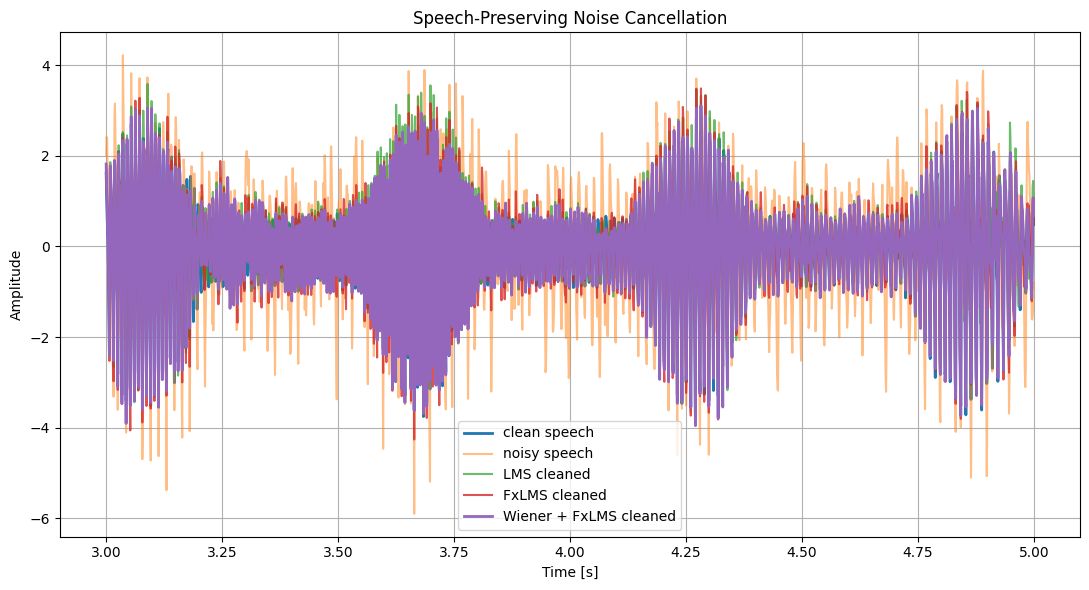

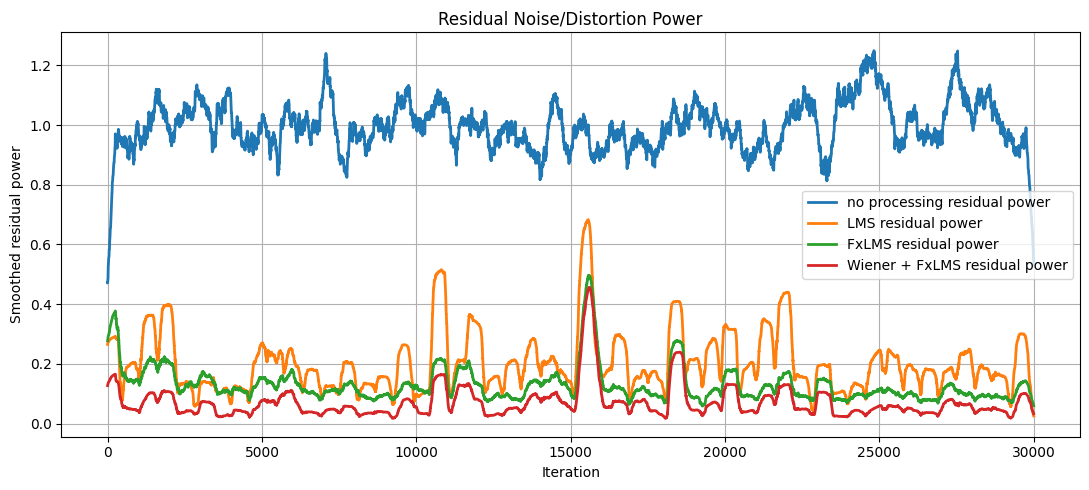

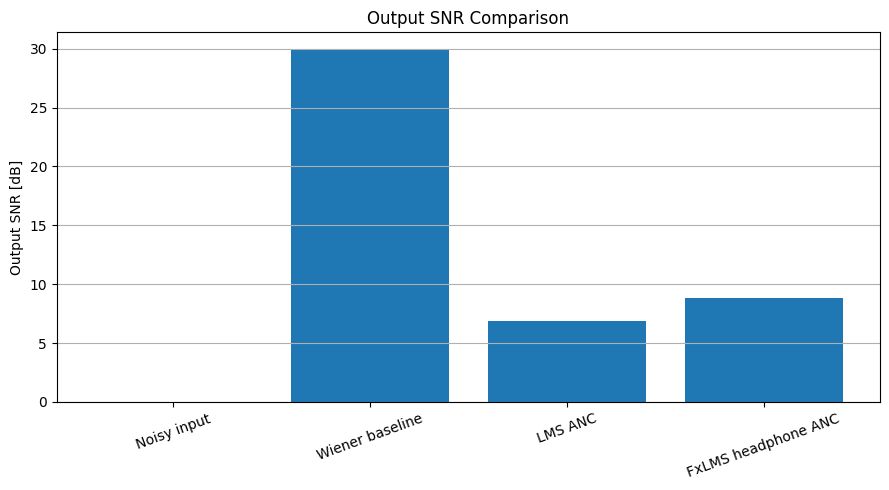

In [11]:
# -------------------------------------------------
# Speech + noise experiment
# -------------------------------------------------
from scipy.io import wavfile
fs = 1000
T = 30
N = int(fs * T)

# Adaptive filter length
M_speech = 32

# NLMS-style step sizes
mu_lms_speech = 0.2
mu_fxlms_speech = 0.08

# Desired input SNR in dB
input_snr_db = 0

# Reference leakage:
# alpha = 0 means reference microphone contains only noise.
# Larger alpha means speech leaks into the reference, causing speech distortion.
alpha_speech_leakage = 0.0

# -------------------------------------------------
# Generate clean speech and base noise
# -------------------------------------------------

speech = make_synthetic_speech(fs, T, seed=10)
base_noise = make_engine_like_noise(fs, T, seed=20)

# Different acoustic paths for primary and reference microphones
h_primary_noise = np.array([0.9, 0.35, -0.20, 0.10])
h_reference_noise = np.array([0.4, 0.75, 0.25, -0.10])

primary_noise_raw = fir_filter(base_noise, h_primary_noise)
reference_noise_raw = fir_filter(base_noise, h_reference_noise)

primary_noise_raw = normalize(primary_noise_raw)
reference_noise_raw = normalize(reference_noise_raw)

# Scale primary noise to desired SNR.
# Use same scale on reference noise so the reference remains physically related.
primary_noise, noise_scale = scale_noise_to_snr(
    clean=speech,
    noise=primary_noise_raw,
    snr_db=input_snr_db,
)

reference_noise = noise_scale * reference_noise_raw

# Optional speech leakage into reference microphone
reference_noise_leaky = reference_noise + alpha_speech_leakage * speech

# Noisy microphone signal
noisy_speech = speech + primary_noise

print("Input SNR:", snr_db(speech, noisy_speech), "dB")

# -------------------------------------------------
# Run ordinary LMS ANC
# -------------------------------------------------

lms_speech = run_lms_speech_anc(
    speech=speech,
    primary_noise=primary_noise,
    reference_noise=reference_noise_leaky,
    M=M_speech,
    mu=mu_lms_speech,
    normalized=True,
)

# -------------------------------------------------
# Run Wiener / least-squares baseline
# -------------------------------------------------

wiener_speech = run_wiener_speech_anc(
    speech=speech,
    primary_noise=primary_noise,
    reference_noise=reference_noise_leaky,
    M=M_speech,
    reg=1e-5,
)

# -------------------------------------------------
# Run FxLMS headphone-style ANC
# -------------------------------------------------

# Actual secondary path: headphone speaker + acoustic path
secondary_path = np.array([0.0, 0.85, 0.25, -0.10])

# Estimated secondary path.
# Start with perfect model. Later, perturb this to test mismatch.
secondary_path_hat = np.array([0.0, 0.85, 0.25, -0.10])

fxlms_speech = run_fxlms_headphone_anc(
    speech=speech,
    primary_noise=primary_noise,
    reference_noise=reference_noise_leaky,
    secondary_path=secondary_path,
    secondary_path_hat=secondary_path_hat,
    M=M_speech,
    mu=mu_fxlms_speech,
    normalized=True,
)

# -------------------------------------------------
# Run combined Wiener-initialized FxLMS ANC
# -------------------------------------------------

combined_speech = run_wiener_initialized_fxlms_speech_anc(
    speech=speech,
    primary_noise=primary_noise,
    reference_noise=reference_noise_leaky,
    secondary_path=secondary_path,
    secondary_path_hat=secondary_path_hat,
    M=M_speech,
    mu=mu_fxlms_speech,
    reg=1e-5,
    normalized=True,
)

# -------------------------------------------------
# Metrics
# -------------------------------------------------

methods = {
    "Noisy input": noisy_speech,
    "Wiener baseline": wiener_speech["z_cleaned"],
    "LMS ANC": lms_speech["z_cleaned"],
    "FxLMS headphone ANC": fxlms_speech["z_cleaned"],
}

print("\nSpeech-preserving noise-cancellation metrics")
print("-------------------------------------------------")
for name, z in methods.items():
    out_snr = snr_db(speech, z)
    improvement = out_snr - snr_db(speech, noisy_speech)
    distortion = speech_distortion(speech, z)

    print(f"{name:22s} | Output SNR = {out_snr:8.3f} dB | "
          f"SNR improvement = {improvement:8.3f} dB | "
          f"D_s = {distortion:10.6f}")

# -------------------------------------------------
# Plot 1: waveform comparison
# -------------------------------------------------

start_sec = 3
duration_sec = 2

i0 = int(start_sec * fs)
i1 = int((start_sec + duration_sec) * fs)

t = np.arange(N) / fs

plt.figure(figsize=(11, 6))

plt.plot(t[i0:i1], speech[i0:i1], label="clean speech", linewidth=2)
plt.plot(t[i0:i1], noisy_speech[i0:i1], label="noisy speech", alpha=0.5)
plt.plot(t[i0:i1], lms_speech["z_cleaned"][i0:i1], label="LMS cleaned", alpha=0.7)
plt.plot(t[i0:i1], fxlms_speech["z_cleaned"][i0:i1], label="FxLMS cleaned", alpha=0.8)
plt.plot(
    t[i0:i1],
    combined_speech["z_cleaned"][i0:i1],
    label="Wiener + FxLMS cleaned",
    linewidth=2,
)

plt.title("Speech-Preserving Noise Cancellation")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# -------------------------------------------------
# Plot 2: residual noise/distortion power
# -------------------------------------------------

noisy_residual_power = (noisy_speech - speech) ** 2
lms_residual_power = lms_speech["residual"] ** 2
fxlms_residual_power = fxlms_speech["residual"] ** 2
combined_residual_power = combined_speech["residual"] ** 2

smooth_window = 500

plt.figure(figsize=(11, 5))

plt.plot(
    moving_average(noisy_residual_power, smooth_window),
    label="no processing residual power",
    linewidth=2,
)

plt.plot(
    moving_average(lms_residual_power, smooth_window),
    label="LMS residual power",
    linewidth=2,
)

plt.plot(
    moving_average(fxlms_residual_power, smooth_window),
    label="FxLMS residual power",
    linewidth=2,
)

plt.plot(
    moving_average(combined_residual_power, smooth_window),
    label="Wiener + FxLMS residual power",
    linewidth=2,
)

plt.title("Residual Noise/Distortion Power")
plt.xlabel("Iteration")
plt.ylabel("Smoothed residual power")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Plot 3: SNR comparison
# -------------------------------------------------

snr_values = [snr_db(speech, z) for z in methods.values()]

plt.figure(figsize=(9, 5))
plt.bar(list(methods.keys()), snr_values)
plt.title("Output SNR Comparison")
plt.ylabel("Output SNR [dB]")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()